https://www.kaggle.com/competitions/ventilator-pressure-prediction/overview

## System Description

We are modeling a **mechanical ventilator** with two valves that control airflow during inspiration and expiration.

**Goal:** predict the airway pressure after the inspiratory solenoid valve opens and air is delivered to the lung. The predicted pressure is used to decide when to open the expiratory valve. The data is a time series of individual breath cycles.

### Inspiratory phase

Air comes from the source and is stabilized by a pressure regulator.

- **`u_in`** is a continuous control input in the range **[0, 100]**. It is the percentage the inspiratory valve is open:
  - `0`: valve closed, no air delivered
  - `100`: valve fully open

  It controls both the volume and the rate of airflow into the lung.
- **`u_out`** stays closed during this phase, so pressure inside the lung rises.

### Expiratory phase

The pressure sensor reading (the target we predict) decides when to open the expiratory valve.

- **`u_out`** is a binary control input: the expiratory valve is either **open (1)** or **closed (0)**.
- When the valve opens, air leaves the lung. It is closed again at a certain point so the lung does not collapse completely.

### Lung parameters

Each breath has two physical parameters of the patient's lung:

| Parameter | Meaning | Effect on pressure |
|-----------|---------|--------------------|
| **R**: airway resistance | How narrow the airways are. Think of blowing up a balloon through a straw: the narrower the straw, the larger the pressure difference needed to push the same flow through it. | Early in inspiration the flow is high and the lung is almost empty, so pressure is dominated by the resistive term **R · flow**. A higher R gives a higher, sharper pressure peak. |
| **C**: lung compliance | How easily the elastic lung tissue stretches. | A low compliance C needs a higher pressure to inflate the lung to the same volume (**V / C** term). |


## Columns description from kaggle

| Column | Description |
|--------|-------------|
| `id` | Unique identifier of a time step across the whole file. |
| `breath_id` | Identifier of a breath cycle. |
| `R` | Lung attribute describing **airway resistance**: the change in pressure per unit change in flow (cmH₂O/L/s). Intuition: blowing up a balloon through a straw. Changing the straw's diameter changes R. The higher the value, the harder it is to blow. |
| `C` | Lung **compliance**: the change in volume per unit change in pressure (mL/cmH₂O). In the balloon analogy, C is set by the thickness of the latex. The higher C is, the thinner the latex and the easier the balloon inflates. |
| `time_step` | Actual timestamp. |
| `u_in` | Control input for the inspiratory solenoid valve, from 0 to 100. |
| `u_out` | Control input for the expiratory valve, either 0 or 1. |
| `pressure` | Airway pressure measured in the respiratory circuit (cmH₂O). |


All information in the next cell obtained from this chat this Gemini: https://share.gemini.google/8smR8XPyelsJ. I talk about theory of that process, and what feature can be useful to add. 

In [163]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

In [165]:
train_df.columns

Index(['id', 'breath_id', 'R', 'C', 'time_step', 'u_in', 'u_out', 'pressure'], dtype='object')

In [166]:
test_df.columns

Index(['id', 'breath_id', 'R', 'C', 'time_step', 'u_in', 'u_out'], dtype='object')

In [167]:
train_df.head(20)

,id,breath_id,R,C,time_step,u_in,u_out,pressure
0,1,1,20,50,0.000000,0.083334,0,5.837492
1,2,1,20,50,0.033652,18.383041,0,5.907794
2,3,1,20,50,0.067514,22.509278,0,7.876254
3,4,1,20,50,0.101542,22.808822,0,11.742872
4,5,1,20,50,0.135756,25.355850,0,12.234987
5,6,1,20,50,0.169698,27.259866,0,12.867706
6,7,1,20,50,0.203708,27.127486,0,14.695562
7,8,1,20,50,0.237723,26.807732,0,15.890699
8,9,1,20,50,0.271776,27.864715,0,15.539188
9,10,1,20,50,0.305732,28.313036,0,15.750094


In [168]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6036000 entries, 0 to 6035999
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   breath_id  int64  
 2   R          int64  
 3   C          int64  
 4   time_step  float64
 5   u_in       float64
 6   u_out      int64  
 7   pressure   float64
dtypes: float64(3), int64(5)
memory usage: 368.4 MB


After reviewing the experiment description and the mechanics of breathing, I formulated several hypotheses about additional features. The main idea is that pressure depends on the current control input, the previous state of the system, and the operation of the controller.

In the simplest model, this relationship is described by the equation:

$$
P(t)=RQ(t)+\frac{V(t)}{C}+PEEP. 
$$

An equivalent form is $$P(t) = P_{res}(t) + P_{elast}(t) + PEEP$$

Here $P(t)$ is the pressure at the airway opening, $Q(t)$ is the flow into the lung, $R$ is the resistance, and $C$ is the compliance. The volume $V(t)$ is measured from the equilibrium volume at the baseline pressure $PEEP$. P_res is the pressure drop needed to move air through the airway resistance.
P_elast is the elastic pressure that comes from the increase in lung volume. 

The volume depends on the previous flow:

$$
V(t)=V(t_0)+\int_{t_0}^{t}Q(s)\,ds,
$$

where $t_0$ is the initial moment. The formula shows that we need to take into account how much air has already entered. The dataset has no measured flow, so we cannot measure the volume. However, we can track the history of volume control through the cumulative sum of `u_in × Δt` within one breath cycle.

The local change of the signal also matters. For constant $R$, $C$ and $PEEP$, the change in pressure between two moments is given by

$$
\Delta P=R\,\Delta Q+\frac{\Delta V}{C}.
$$

During inspiration, the volume can grow even while the flow decreases. The elastic component of pressure then increases and the resistive component decreases. So pressure does not have to change in the same direction as the input.

Therefore, we need to check previous values of `u_in` and the differences between adjacent samples. They describe how the signal changed over time to regulate these pressures.

The parameters $R$ and $C$ set the conditions under which the system responds to control. Their nine combinations in the dataset correspond to configurations of the artificial lung, so they can be tested as separate categories using one-hot encoding.

Besides the mechanics, feedback also affects the signals. Let $P^\ast(t)$ be the target pressure and $P_m(t)$ the measured pressure. For the simplest model, the following formula holds:

$$
u(t)=K_P\bigl(P^\ast(t)-P_m(t)\bigr).
$$

Here $u(t)$ is the dimensionless valve command, and $K_P>0$ is a tuned gain in units of inverse pressure. With a constant setpoint, a rise in measured pressure lowers the command.

So `u_in` may carry information about how the controller responds to pressure. The maximum command over a cycle and the deviations from its maximum and mean may describe the control mode used to change pressure.

In this task the whole cycle is available in advance, so these characteristics can be computed for each cycle separately, and in a sense we can look into the future of the control actions.

The prediction is made for a cycle that has already been recorded, so the next values of the command are also available. They describe how the control system responds next and can add information about the current state.


### Missing value exploration

In [169]:
train_df.isnull().sum()

id           0
breath_id    0
R            0
C            0
time_step    0
u_in         0
u_out        0
pressure     0
dtype: int64

In [ ]:
train_df.groupby("breath_id").size().value_counts()

80    75450
Name: count, dtype: int64

In [171]:
test_df.isnull().sum()

id           0
breath_id    0
R            0
C            0
time_step    0
u_in         0
u_out        0
dtype: int64

In [ ]:
test_df.groupby("breath_id").size().value_counts()

80    50300
Name: count, dtype: int64

There are no missing values.

### Data leakage exploration

In [ ]:
train_df_without_pressure = train_df.drop(columns=["pressure"])
breath_id_diff = pd.merge(
    train_df_without_pressure, test_df, on="breath_id", how="inner"
)
print(
    f"Number of the same breath_id in train and test: {breath_id_diff['breath_id'].nunique()}"
)

Number of the same breath_id in train and test: 0


In [ ]:
sigs = {}
for name, df in [("train", train_df), ("test", test_df)]:
    s = (
        df.sort_values(["breath_id", "time_step"])
        .assign(u_in=lambda d: d["u_in"].round(4))
        .groupby(["breath_id", "R", "C"])["u_in"]
        .agg(tuple)
        .reset_index()
    )
    s = s[s["u_in"].map(any)]
    sigs[name] = list(zip(s["R"], s["C"], s["u_in"]))

print("Duplicates in train:", len(sigs["train"]) - len(set(sigs["train"])))
print("Common breaths in train/test:", len(set(sigs["train"]) & set(sigs["test"])))

Duplicates in train: 0
Common breaths in train/test: 0


In [ ]:
# Does breath_id carry a time order?
print(
    "breath_id range - train:",
    train_df["breath_id"].min(),
    "-",
    train_df["breath_id"].max(),
    "| test:",
    test_df["breath_id"].min(),
    "-",
    test_df["breath_id"].max(),
)

breath_means = train_df.groupby("breath_id").agg(
    pressure=("pressure", "mean"),
    u_in=("u_in", "mean"),
    R=("R", "first"),
    C=("C", "first"),
)
breath_means.groupby(pd.qcut(breath_means.index, 10, labels=False)).mean().round(2)

breath_id range - train: 1 - 125749 | test: 0 - 125748


,pressure,u_in,R,C
0,11.24,7.39,26.84,26.18
1,11.29,7.37,27.22,25.69
2,11.17,7.28,26.87,25.99
3,11.25,7.37,26.96,26.14
4,11.30,7.43,26.95,25.73
5,11.19,7.27,27.16,26.12
6,11.16,7.17,27.26,26.09
7,11.16,7.29,27.11,26.18
8,11.24,7.34,27.05,26.21
9,11.20,7.30,26.95,26.49


**Insights: `id` and `breath_id`**

- **Distribution:** every breath has exactly 80 rows (75,450 breaths in train, 50,300 in test). Rows inside a breath are dependent, so `breath_id` is the natural group.
- **Train vs test:** no `breath_id` is shared, and the ids of the two sets are interleaved. Apart from the 14 train breaths with `u_in ≡ 0`, which the check skips, there are no duplicate `u_in` sequences within train or across the split. 
- **Decision:** `breath_id` is the group for validation; neither id is used as a feature.

### Target exploration

In [ ]:
# Local helpers used below
insp = train_df["u_out"] == 0
scored_df = train_df[insp]
step = train_df.groupby("breath_id").cumcount().rename("step")
rc = (
    (train_df["R"].astype(str) + "_" + train_df["C"].astype(str))
    .astype("category")
    .rename("R_C")
)
breath_rc = (
    train_df.groupby("breath_id")[["R", "C"]].first().astype(str).agg("_".join, axis=1)
)

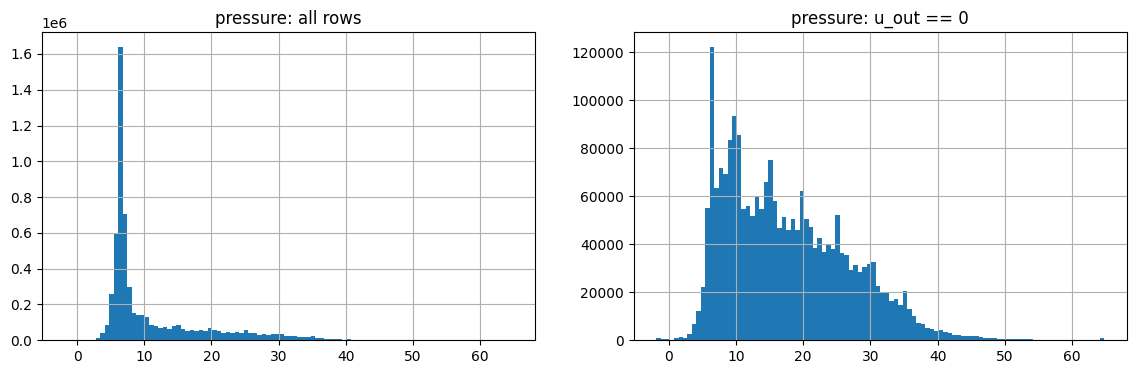

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_df["pressure"].hist(bins=100, ax=axes[0])
axes[0].set_title("pressure: all rows")
scored_df["pressure"].hist(bins=100, ax=axes[1])
axes[1].set_title("pressure: u_out == 0")
plt.show()

In [ ]:
pressure_stats = pd.DataFrame(
    {"all rows": train_df["pressure"], "u_out == 0": scored_df["pressure"]}
)
pd.concat([pressure_stats.describe(), pressure_stats.agg(["skew", "kurt"])]).round(3)

,all rows,u_out == 0
count,6036000.000,2290968.000
mean,11.220,17.596
std,8.110,9.248
min,-1.896,-1.896
25%,6.330,9.915
50%,7.033,15.820
75%,13.641,23.975
max,64.821,64.821
skew,1.819,0.781
kurt,3.041,0.407


In [ ]:
values = np.sort(train_df["pressure"].unique())
gaps = np.diff(values)
print("Unique pressure values:", len(values))
print(
    "Step between neighbouring values: min",
    gaps.min().round(5),
    "| max",
    gaps.max().round(5),
)

Unique pressure values: 950
Step between neighbouring values: min 0.0703 | max 0.0703


In [ ]:
# Sanity check and baseline
print(
    "Mean absolute deviation from the median (scored rows):",
    round((scored_df["pressure"] - scored_df["pressure"].median()).abs().mean(), 3),
)

Mean absolute deviation from the median (scored rows): 7.516


**Insights: `pressure` (target)**

- The data is discrete — because of the ADC on the PID controller, there are only ~950 unique values, so a model's output can be snapped to the nearest ADC step. The task can be framed either as regression or as multi-class classification.
- Only the inspiration phase is scored, so the distribution must be examined exclusively in that context. So, it is possible to modify our loss function only to those values.
- There are negative-pressure anomalies present. So, we need to check, whether it is possible, is it anomaly.
- The scored distribution is close to normal, based on skew and kurtosis. So we can you MAE/MSE loss function without need to perform log transformation, or find some robust loss
- Sanity check for models: if the score is worse than 7.516, the model is clearly not working.

### Time exploration

In [ ]:
time = train_df.groupby("breath_id")["time_step"]

time.first().describe()

count    75450.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: time_step, dtype: float64

In [182]:
time.last().describe()

count    75450.000000
mean         2.614803
std          0.087102
min          2.496809
25%          2.523674
50%          2.655257
75%          2.689902
max          2.937238
Name: time_step, dtype: float64

In [183]:
time_difference = time.diff()
time_difference.describe().round(3)

count    5960550.000
mean           0.033
std            0.001
min            0.031
25%            0.032
50%            0.033
75%            0.034
max            0.251
Name: time_step, dtype: float64

In [ ]:
test_dt = test_df.groupby("breath_id")["time_step"].diff()
print(
    "Breaths with dt > 0.04 - train:",
    train_df.loc[time_difference > 0.04, "breath_id"].nunique(),
    "| test:",
    test_df.loc[test_dt > 0.04, "breath_id"].nunique(),
)

Breaths with dt > 0.04 - train: 65 | test: 35


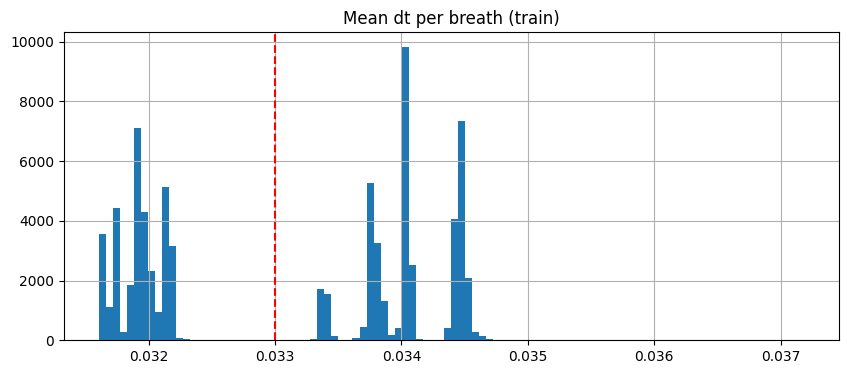

Share of slow-sampling breaths - train: 0.546 | test: 0.545
Mean inspiratory pressure by regime (False = fast, True = slow): {False: 18.66, True: 16.64}


slow regime,False,True
R_C,,
20_10,0.31,0.69
20_20,0.31,0.69
20_50,0.23,0.77
50_10,0.45,0.55
50_20,0.75,0.25
50_50,0.75,0.25
5_10,0.23,0.77
5_20,0.76,0.24
5_50,0.23,0.77


In [ ]:
# Mean dt of each breath: two sampling regimes
breath_dt = time_difference.groupby(train_df["breath_id"]).mean()
test_breath_dt = test_dt.groupby(test_df["breath_id"]).mean()

breath_dt.hist(bins=100, figsize=(10, 4))
plt.axvline(0.033, color="red", linestyle="--")
plt.title("Mean dt per breath (train)")
plt.show()

slow = breath_dt > 0.033
print(
    "Share of slow-sampling breaths - train:",
    round(slow.mean(), 3),
    "| test:",
    round((test_breath_dt > 0.033).mean(), 3),
)
print(
    "Mean inspiratory pressure by regime (False = fast, True = slow):",
    scored_df.groupby("breath_id")["pressure"]
    .mean()
    .groupby(slow)
    .mean()
    .round(2)
    .to_dict(),
)
pd.crosstab(
    breath_rc.rename("R_C"), slow.rename("slow regime"), normalize="index"
).round(2)

In [ ]:
print(
    "Spearman(time_step, pressure) on scored rows:",
    round(scored_df["time_step"].corr(scored_df["pressure"], method="spearman"), 3),
)

Spearman(time_step, pressure) on scored rows: 0.474


**Insights: `time_step`**

-  time is measured only within a single breath — there is no global timestamp. Every breath starts at 0 and lasts 2.5–2.9 s. Sampling is not uniform.

-  the mean Δt per breath is bimodal — ≈0.032 s (fast regime) and ≈0.034 s (slow regime), split roughly 45%/55%. The share of each regime depends on R_C.

-  Spearman on scored rows  show that pressure also differs between regimes.

- regime shares are nearly identical so, there is no distribution shift between train and test along this dimension.

- so we need  keep time_step, compute Δt explicitly and add it as a feature.

In [ ]:
print(train_df["R"].unique())
print(train_df["C"].unique())
print(test_df["R"].unique())
print(test_df["C"].unique())

[20 50  5]
[50 20 10]
[ 5 50 20]
[20 50 10]


### Lung Parameters

In reality R and C are continuous. The dataset uses 3 values of each.

**R: airway resistance (cmH₂O/L/s).** How hard it is to push air through the airways.

| R | Meaning |
|---|---------|
| 5  | Normal airways |
| 20 | Moderate narrowing (bronchospasm) |
| 50 | Severe narrowing (asthma): sharp pressure spike when flow starts |

**C: lung compliance (mL/cmH₂O).** How much air the lung takes per unit of pressure. Higher C means a softer lung.

| C | Meaning |
|---|---------|
| 50 | Normal lung |
| 20 | Stiff lung (pneumonia) |
| 10 | Very stiff lung  (barotrauma) |

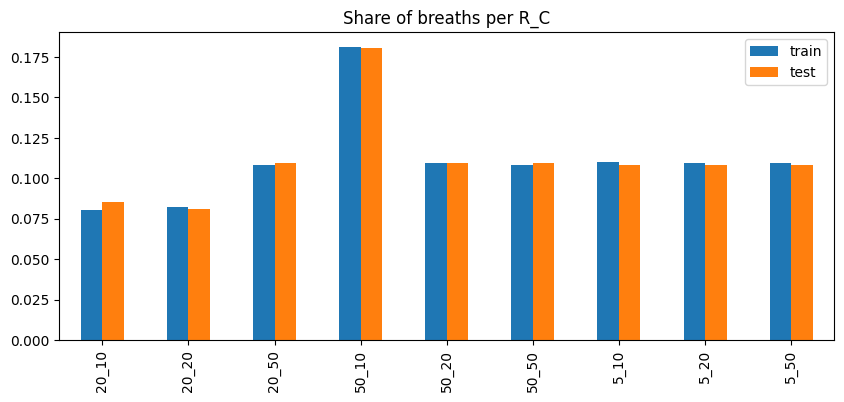

,train,test
20_10,0.080,0.085
20_20,0.082,0.081
20_50,0.108,0.109
50_10,0.181,0.181
50_20,0.109,0.109
50_50,0.109,0.109
5_10,0.110,0.108
5_20,0.110,0.108
5_50,0.110,0.108


In [ ]:
breath_rc_test = (
    test_df.groupby("breath_id")[["R", "C"]].first().astype(str).agg("_".join, axis=1)
)
rc_share = pd.DataFrame(
    {
        "train": breath_rc.value_counts(normalize=True),
        "test": breath_rc_test.value_counts(normalize=True),
    }
).sort_index()
rc_share.plot.bar(figsize=(10, 4), title="Share of breaths per R_C")
plt.show()
rc_share.round(3)

In [ ]:
print(scored_df.groupby("R")["pressure"].mean().round(2))
print(scored_df.groupby("C")["pressure"].mean().round(2))
scored_df.pivot_table(index="R", columns="C", values="pressure", aggfunc="mean").round(
    2
)

R
5     16.73
20    17.97
50    18.05
Name: pressure, dtype: float64
C
10    18.49
20    17.85
50    16.33
Name: pressure, dtype: float64


C,10,20,50
R,,,
5,19.28,16.28,14.62
20,19.95,17.90,16.52
50,17.37,19.39,17.82


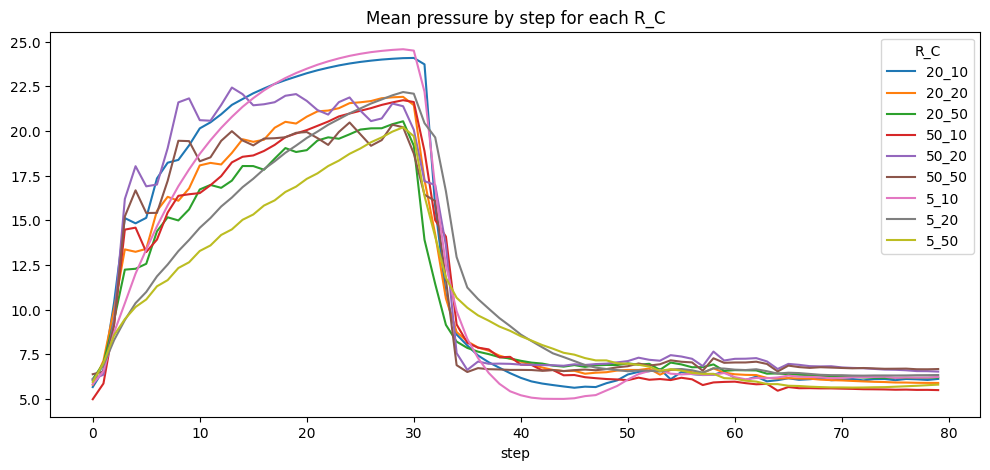

In [ ]:
curves = train_df.groupby([step, rc], observed=True)["pressure"].mean().unstack()
curves.plot(figsize=(12, 5), title="Mean pressure by step for each R_C")
plt.show()

**Insights: `R` and `C`**

- **Distribution:** three values each, which gives 9 combinations `R_C`. The R=50, C=10 group holds 18% of breaths, the others 8–11%.
- **Link to pressure:** mean inspiratory pressure grows with R (16.7 → 18.1) and falls with C (18.5 → 16.3). The R×C table is not monotone.
- **Train vs test:** the shares of all 9 combinations are the same.
- **Decision:** treat R and C as categories: one-hot for `R`, `C` and `R_C`, or an embedding for `R_C`. Stratify the train/validation split by `R_C`.

### `u_out`: expiratory valve

In [ ]:
print(
    "Share of u_out == 0 - train:",
    round((train_df["u_out"] == 0).mean(), 4),
    "| test:",
    round((test_df["u_out"] == 0).mean(), 4),
)

opened = train_df["u_out"] == 1
first_open = step[opened].groupby(train_df.loc[opened, "breath_id"]).min()
print(
    "Transitions 1 -> 0:", (train_df.groupby("breath_id")["u_out"].diff() == -1).sum()
)
print("Step where u_out first becomes 1:")
first_open.value_counts().sort_index()

Share of u_out == 0 - train: 0.3796 | test: 0.3796
Transitions 1 -> 0: 0
Step where u_out first becomes 1:


step
25       10
26        3
28      123
29    22803
30    18260
31    17923
32    16328
Name: count, dtype: int64

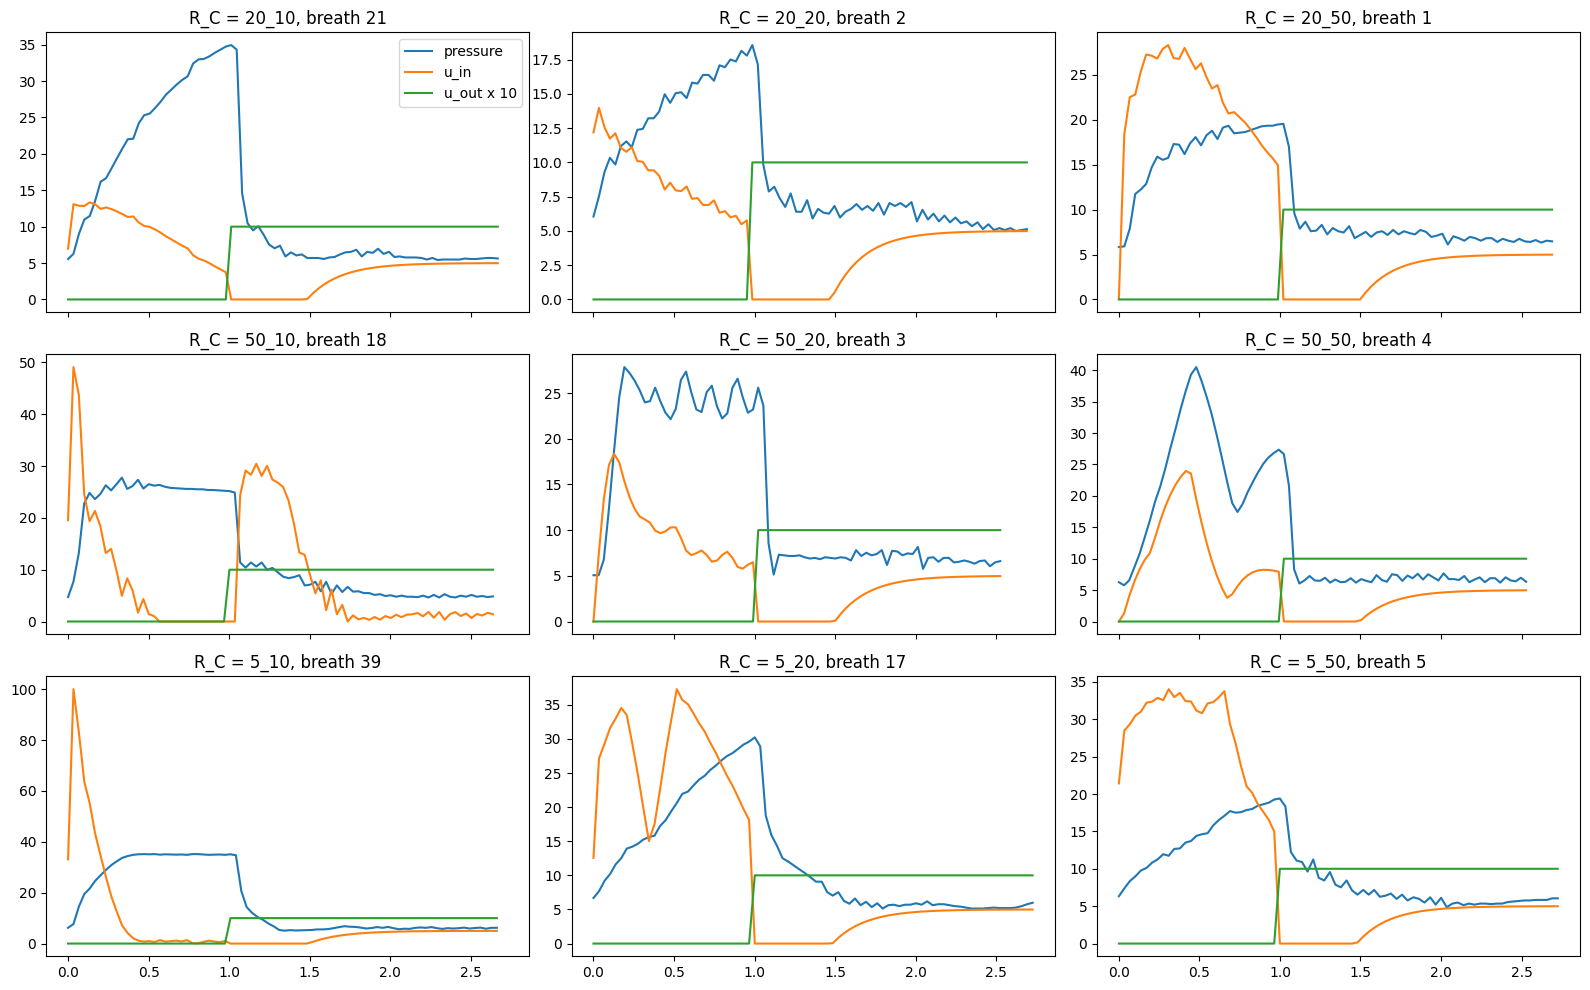

In [ ]:
# One example breath per R_C
examples = breath_rc.groupby(breath_rc).head(1).sort_values()
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
for ax, (breath_id, name) in zip(axes.flat, examples.items()):
    b = train_df[train_df["breath_id"] == breath_id]
    ax.plot(b["time_step"], b["pressure"], label="pressure")
    ax.plot(b["time_step"], b["u_in"], label="u_in")
    ax.plot(b["time_step"], b["u_out"] * 10, label="u_out x 10")
    ax.set_title(f"R_C = {name}, breath {breath_id}")
axes[0, 0].legend()
plt.tight_layout()
plt.show()

**Insights: `u_out`**

- **Distribution:** about 38% of rows have `u_out == 0`. The valve opens once, at step 25–32 (0-based), and never closes again, so inspiration is always a prefix of the breath.
- **Link to pressure:** `u_out` defines the scored rows and is constant on them.
- **Train vs test:** the share of `u_out == 0` is 37.96% in both.
- **Decision:** `u_out` is a phase marker. `pressure` is analysed on `u_out == 0` rows, and expiration rows stay in the data.

### `u_in`: inspiratory valve command

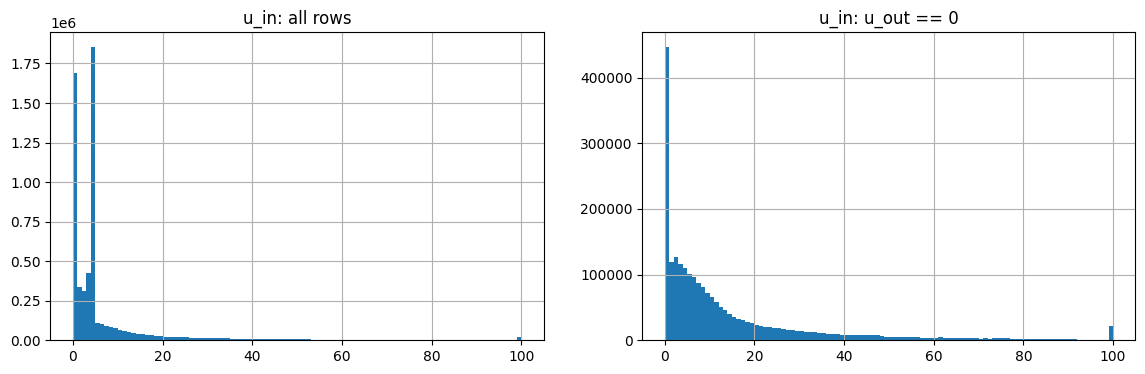

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_df["u_in"].hist(bins=100, ax=axes[0])
axes[0].set_title("u_in: all rows")
scored_df["u_in"].hist(bins=100, ax=axes[1])
axes[1].set_title("u_in: u_out == 0")
plt.show()

In [ ]:
print(
    "Share of u_in == 0 - train:",
    round((train_df["u_in"] == 0).mean(), 4),
    "| test:",
    round((test_df["u_in"] == 0).mean(), 4),
)
print(
    "Skew - all rows:",
    round(train_df["u_in"].skew(), 2),
    "| scored rows:",
    round(scored_df["u_in"].skew(), 2),
)
print(
    "Spearman(u_in, pressure) on scored rows:",
    round(scored_df["u_in"].corr(scored_df["pressure"], method="spearman"), 3),
)

zero_breaths = train_df.groupby("breath_id")["u_in"].max() == 0
print("Breaths with u_in == 0 everywhere:", zero_breaths.sum())
breath_rc[zero_breaths].value_counts()

Share of u_in == 0 - train: 0.2373 | test: 0.2369
Skew - all rows: 3.91 | scored rows: 2.25
Spearman(u_in, pressure) on scored rows: 0.159
Breaths with u_in == 0 everywhere: 14


50_10    14
Name: count, dtype: int64

**Insights: `u_in`**

- **Distribution:** from 0 to 100, with about 24% of rows exactly 0. Strongly right-skewed (skew 3.9 on all rows, 2.25 on scored rows). 14 breaths have `u_in ≡ 0`, all with R=50, C=10.
- **Link to pressure:** the instantaneous link is weak (Spearman 0.16 on scored rows). 
- **Train vs test:** the share of zeros is 23.7% in both, and the distributions overlap.
- **Decision:** keep `u_in` and build history features from it.

### Train/test distribution shift

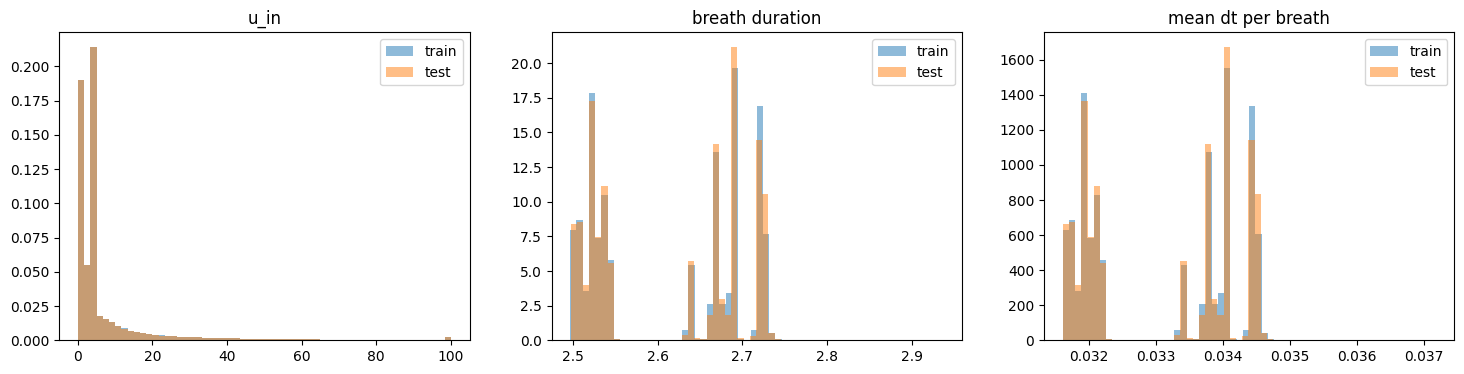

In [ ]:
comparisons = {
    "u_in": (train_df["u_in"], test_df["u_in"]),
    "breath duration": (time.last(), test_df.groupby("breath_id")["time_step"].last()),
    "mean dt per breath": (breath_dt, test_breath_dt),
}
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (name, (tr, te)) in zip(axes, comparisons.items()):
    ax.hist(tr, bins=60, density=True, alpha=0.5, label="train")
    ax.hist(te, bins=60, density=True, alpha=0.5, label="test")
    ax.set_title(name)
    ax.legend()
plt.show()

In [ ]:
pd.DataFrame(
    {
        "train": [
            (train_df["u_out"] == 0).mean(),
            (train_df["u_in"] == 0).mean(),
            (breath_dt > 0.033).mean(),
        ],
        "test": [
            (test_df["u_out"] == 0).mean(),
            (test_df["u_in"] == 0).mean(),
            (test_breath_dt > 0.033).mean(),
        ],
    },
    index=["scored rows", "u_in == 0", "slow dt regime"],
).round(4)

,train,test
scored rows,0.3796,0.3796
u_in == 0,0.2373,0.2369
slow dt regime,0.5462,0.5447


**Insights**

- All the *Train vs test* checks above match: the shares of `R_C`, of scored rows, of zero `u_in` and of the Δt regimes, and the distributions of `u_in` and breath duration. There is no shift between train and test.

### Outliers

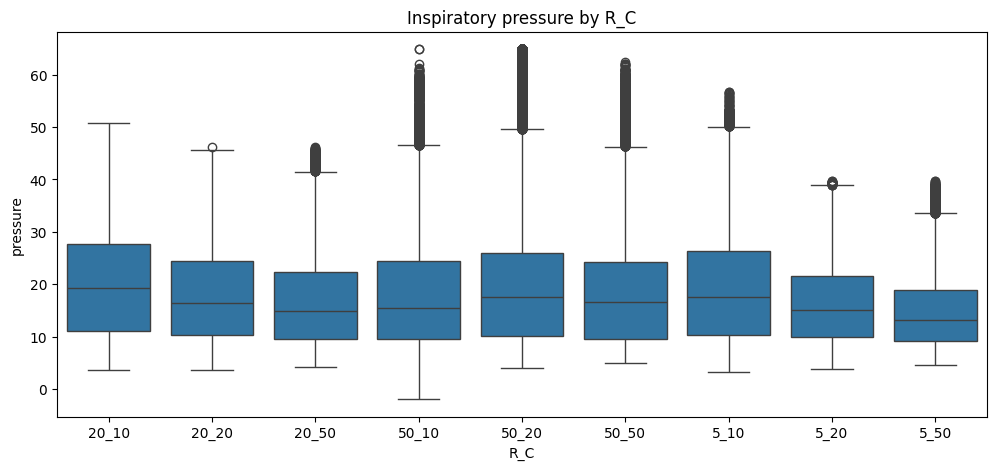

In [ ]:
plt.figure(figsize=(12, 5))
sns.boxplot(x=rc[insp], y=scored_df["pressure"])
plt.title("Inspiratory pressure by R_C")
plt.show()

In [ ]:
# Breaths whose inspiratory pressure never rises above 3
breath_max_p = scored_df.groupby("breath_id")["pressure"].max()
low_p = breath_max_p[breath_max_p < 3].index
print("Breaths with max inspiratory pressure < 3:", len(low_p))
print("Their R_C:", breath_rc[low_p].value_counts().to_dict())
print(
    "Max u_in in these breaths:",
    scored_df[scored_df["breath_id"].isin(low_p)]
    .groupby("breath_id")["u_in"]
    .max()
    .describe()
    .round(2)
    .to_dict(),
)

Breaths with max inspiratory pressure < 3: 74
Their R_C: {'50_10': 74}
Max u_in in these breaths: {'count': 74.0, 'mean': 0.62, 'std': 0.66, 'min': 0.0, '25%': 0.14, '50%': 0.3, '75%': 1.06, 'max': 2.03}


In [ ]:
# Similar low-input breaths in train and test
low_input = {}
for name, df in [("train", train_df), ("test", test_df)]:
    d = (
        df[df["u_out"] == 0]
        .groupby("breath_id")
        .agg(u_in_max=("u_in", "max"), R=("R", "first"), C=("C", "first"))
    )
    low_input[name] = d[d["u_in_max"] <= 2.1].groupby(["R", "C"]).size()
low_input = pd.DataFrame(low_input)
print("Total:", low_input.sum().to_dict())
low_input

Total: {'train': 662, 'test': 464}


train  test
R  C              
5  10     89    44
   20     30    31
   50     29    24
20 10     94    65
   20     44    39
   50     26    20
50 10    247   169
   20     61    43
   50     42    29

In [ ]:
negative = train_df[train_df["pressure"] < 0]
print(
    "Rows with negative pressure:",
    len(negative),
    "| breaths:",
    negative["breath_id"].nunique(),
)
print(
    "Of these breaths, also in the low-pressure group:",
    negative["breath_id"].drop_duplicates().isin(low_p).sum(),
)
print("By phase (u_out):", negative["u_out"].value_counts().to_dict())
print("By R_C:", rc[negative.index].value_counts()[lambda s: s > 0].to_dict())
print("Scored rows with pressure > 64:", (scored_df["pressure"] > 64).sum())

Rows with negative pressure: 3713 | breaths: 73
Of these breaths, also in the low-pressure group: 57
By phase (u_out): {1: 2282, 0: 1431}
By R_C: {'50_10': 3713}
Scored rows with pressure > 64: 982


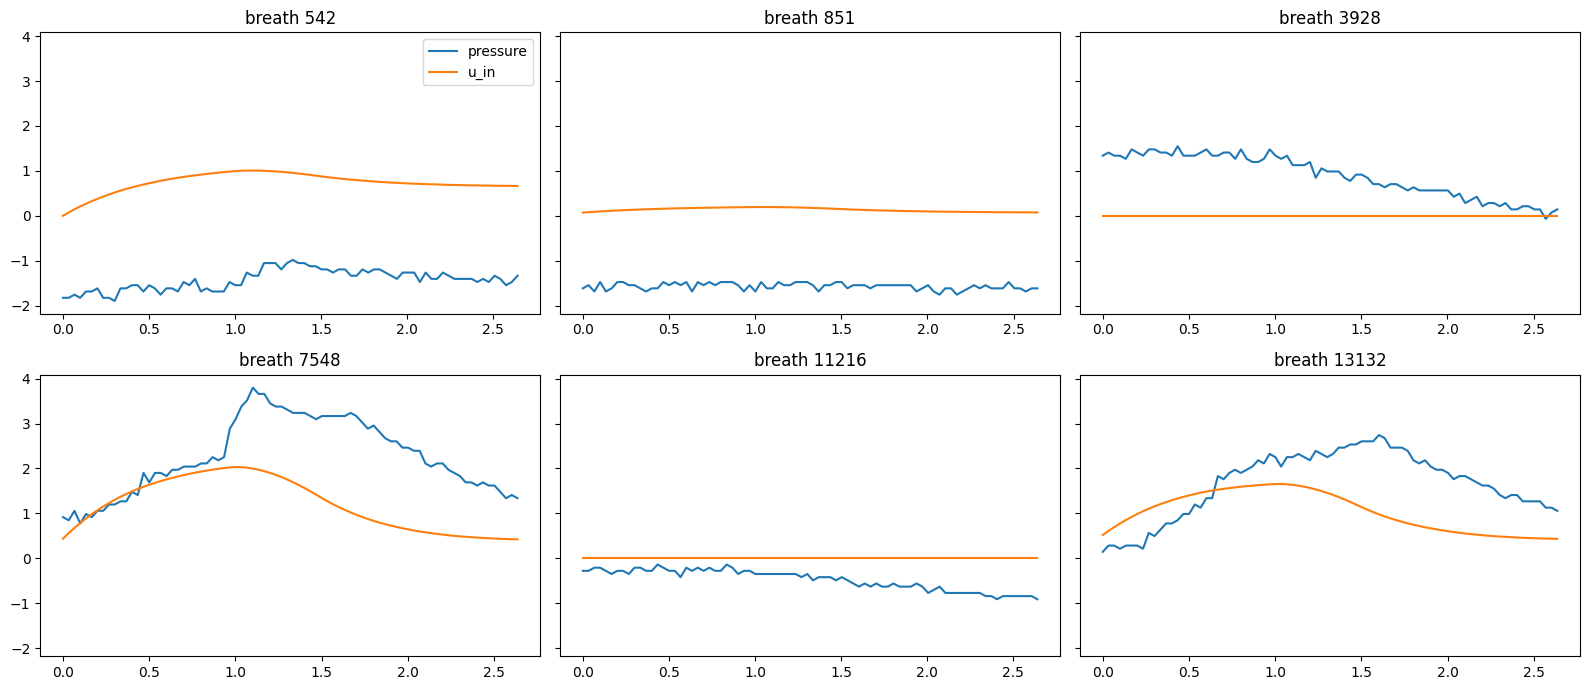

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharey=True)
for ax, breath_id in zip(axes.flat, low_p[:6]):
    b = train_df[train_df["breath_id"] == breath_id]
    ax.plot(b["time_step"], b["pressure"], label="pressure")
    ax.plot(b["time_step"], b["u_in"], label="u_in")
    ax.set_title(f"breath {breath_id}")
axes[0, 0].legend()
plt.tight_layout()
plt.show()

**Insights**

- **Near-zero pressure** (breath maximum below 3): 74 breaths, all R=50, C=10, all with near-zero `u_in` (maximum ≤ 2). The test set has similar breaths (169 low-input breaths with R=50, C=10), so we keep them.
- **Negative pressure:** 3.7k rows in 73 breaths, all R=50, C=10; 57 of these breaths are also in the near-zero group above. Keep them.
- **Ceiling near 64.8:** 982 scored rows lie above 64, which looks like the upper limit of the system. Keep them.
- **Anomalies during expiration:** these rows are not scored, so they need no treatment.
- **Business view:** the task is about the normal pressure curve during inspiration. The outliers are rare and are not the signal we are looking for, so we describe them instead of removing them.

### Validation strategy

**Decision:** one holdout split of `train.csv` (80% train / 20% validation), with `breath_id` as the group and `R_C` as the stratification label. `test.csv` is kept aside for the final score.

**Why group by `breath_id`.** The 80 rows of a breath are consecutive measurements of one process, and each pressure value depends on the previous ones and on the whole command sequence.

**Why stratify by `R_C`.** The nine lung configurations behave differently and are imbalanced: R=50, C=10 holds 18% of breaths, the others 8–11%. Without stratification the validation part can get a different mix of configurations.

**Why no time-based split.** A time split is needed when information from the future must not reach the past. There is no calendar time here: `time_step` is time inside a breath.

**Why one holdout, not K-fold.** There are 75k breaths, so the validation part is large, and train and test have the same distribution (see above), so one split is a reliable estimate. K-fold would multiply the training cost of the network by K.


### Feature investigation


#### 1. Time between samples 

$$\Delta t_i=\begin{cases}0, & i=1\\ t_i-t_{i-1}, & i>1\end{cases}$$

#### 2. Cumulative sum of the command 

$$S_i=\sum_{j=1}^{i}u_j$$


In [ ]:
u_in_cumsum = train_df.groupby("breath_id")["u_in"].cumsum()
print(
    "Spearman with pressure - u_in:",
    round(scored_df["u_in"].corr(p, method="spearman"), 3),
    "| cumsum(u_in):",
    round(u_in_cumsum[insp].corr(p, method="spearman"), 3),
)

Spearman with pressure - u_in: 0.159 | cumsum(u_in): 0.806


**Insight:** Spearman 0.81, against 0.16 for the raw `u_in`.

**Verdict:** keep.

#### 3. Area under the command

$$A_i=\sum_{j=1}^{i}u_j\,\Delta t_j$$

**Hypothesis:** unlike the plain sum, the area takes the intervals into account. 

In [ ]:
area = (train_df["u_in"] * dt).groupby(train_df["breath_id"]).cumsum()
print("corr(cumsum, area):", round(u_in_cumsum.corr(area), 4))
print(
    pd.DataFrame({"cumsum": u_in_cumsum[insp], "area": area[insp], "pressure": p})
    .corr()["pressure"]
    .round(3)
)

corr(cumsum, area): 0.9972
cumsum      0.580
area        0.572
pressure    1.000
Name: pressure, dtype: float64


**Insight:** A is strongly corelated with S, and gives no additional information

**Verdict:** keep $A$; $S$ is redundant.

#### 4. Past and future commands 
$$L_i^{(k)}=\begin{cases}u_{i-k}, & i>k\\ 0, & i\le k\end{cases},\qquad F_i^{(k)}=\begin{cases}u_{i+k}, & i+k\le n\\ 0, & i+k>n\end{cases}\qquad k=1,\dots,4$$

**Hypothesis:** pressure responds to the command with a delay, so past commands ($L$) should help predict it. The controller also reacts to the measured pressure, $u(t)=K_P\,(P^\ast(t)-P_m(t))$, so future commands ($F$) carry information about the current pressure too. Missing values at the edges of a breath are replaced with zeros.

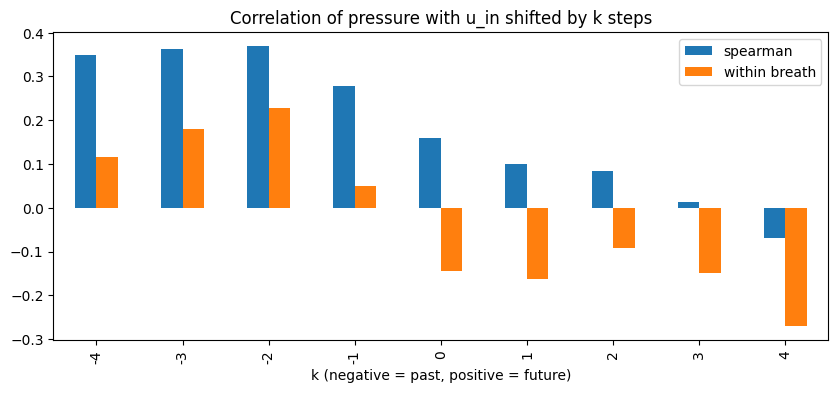

,spearman,within breath
-4,0.349,0.117
-3,0.362,0.180
-2,0.370,0.228
-1,0.278,0.049
0,0.159,-0.144
1,0.100,-0.163
2,0.083,-0.092
3,0.014,-0.149
4,-0.069,-0.270


In [ ]:
# Correlation of pressure with u_in shifted by k steps (k < 0: past, k > 0: future)
g_u_in = train_df.groupby("breath_id")["u_in"]
u_mean = g_u_in.transform("mean")
p_centered = train_df["pressure"] - train_df.groupby("breath_id")["pressure"].transform(
    "mean"
)

cross = {}
for k in range(-4, 5):
    shifted = g_u_in.shift(-k)
    m = insp & shifted.notna()
    cross[k] = {
        "spearman": train_df.loc[m, "pressure"].corr(shifted[m], method="spearman"),
        "within breath": p_centered[m].corr((shifted - u_mean)[m]),
    }
cross = pd.DataFrame(cross).T
cross.plot.bar(
    figsize=(10, 4), title="Correlation of pressure with u_in shifted by k steps"
)
plt.xlabel("k (negative = past, positive = future)")
plt.show()
cross.round(3)

**Insight:** pressure correlates more with `u_in` two to four steps back (≈0.35–0.37) than with the current value (0.16) — the response is delayed by about two steps. In the other direction, after removing each breath's mean, current and future `u_in` correlate negatively with current pressure (−0.14 at k = 0, down to −0.27 at k = 4): when pressure is high, the controller lowers the command, confirming the feedback loop.

**Verdict:** keep both $L$ and $F$.

#### 5. Differences from previous commands 

$$D_i^{(k)}=u_i-L_i^{(k)},\qquad k=1,\dots,4$$

**Hypothesis:** from $\Delta P=R\,\Delta Q+\Delta V/C$, a change in the command should show up as a change in pressure. These are single differences without division by time, not derivatives of different orders.

In [ ]:
dp = train_df.groupby("breath_id")["pressure"].diff()
du = g_u_in.diff()
for r in (5, 20, 50):
    m = insp & dp.notna() & (train_df["R"] == r)
    print(f"R={r}: corr(change in pressure, change in u_in) = {dp[m].corr(du[m]):.3f}")

for k in range(1, 5):
    diff_k = train_df["u_in"] - g_u_in.shift(k).fillna(0)
    print(
        f'Spearman(pressure, u_in - lag{k}): {diff_k[insp].corr(p, method="spearman"):.3f}'
    )

R=5: corr(change in pressure, change in u_in) = -0.214
R=20: corr(change in pressure, change in u_in) = -0.793
R=50: corr(change in pressure, change in u_in) = -0.659
Spearman(pressure, u_in - lag1): -0.412
Spearman(pressure, u_in - lag2): -0.473
Spearman(pressure, u_in - lag3): -0.486
Spearman(pressure, u_in - lag4): -0.470


**Insight:** the step-to-step changes of pressure and `u_in` correlate negatively on scored rows. 

**Verdict:** keep.

#### 6. Maximum command in the breath 

$$M=\max_{1\le j\le n}u_j$$

**Hypothesis:** the maximum describes the control mode of the whole breath. It is the same for all rows of a breath and uses the whole breath, including future steps.

In [ ]:
u_in_max = g_u_in.transform("max")
print(
    "Spearman(max u_in, pressure), rows:",
    round(u_in_max[insp].corr(p, method="spearman"), 3),
)

per_breath = scored_df.groupby("breath_id").agg(
    u_in_max=("u_in", "max"), pressure_max=("pressure", "max")
)
print(
    "Spearman(max u_in, max pressure), breaths:",
    round(
        per_breath["u_in_max"].corr(per_breath["pressure_max"], method="spearman"), 3
    ),
)

Spearman(max u_in, pressure), rows: 0.535
Spearman(max u_in, max pressure), breaths: 0.664


**Insight:** Spearman 0.54 at row level; per breath, max `u_in` and max pressure correlate at 0.66.

**Verdict:** keep.

#### 7. One-hot lung parameters 

$$\mathbf 1[R=r],\ r\in\{5,20,50\};\qquad \mathbf 1[C=c],\ c\in\{10,20,50\};\qquad \mathbf 1[R=r\wedge C=c]$$

**Hypothesis:** each lung configuration responds to control differently. The pair $(R, C)$ is treated as a category, not as a product or ratio.

In [ ]:
# Level and spread of inspiratory pressure for each lung configuration
(
    scored_df.groupby(rc[insp], observed=True)["pressure"]
    .describe()[["25%", "50%", "75%"]]
    .assign(IQR=lambda d: d["75%"] - d["25%"])
    .round(2)
)

,25%,50%,75%,IQR
R_C,,,,
20_10,11.11,19.27,27.77,16.66
20_20,10.34,16.52,24.47,14.13
20_50,9.56,14.98,22.36,12.79
50_10,9.63,15.54,24.40,14.76
50_20,10.13,17.65,25.94,15.82
50_50,9.56,16.59,24.26,14.69
5_10,10.41,17.65,26.30,15.89
5_20,9.92,15.19,21.51,11.60
5_50,9.21,13.15,18.98,9.77


**Insight:** the level and shape of the pressure curve differ by `R_C`, and the interaction of R and C is not monotone.

**Verdict:** keep.

#### Scaling

Mean $\mu$ and standard deviation $\sigma$ of the numeric features, computed on train only.

In [ ]:
numeric = pd.DataFrame(
    {
        "u_in": train_df["u_in"],
        "time_step": train_df["time_step"],
        "dt": dt,
        "cumsum": u_in_cumsum,
        "area": area,
    }
)
numeric.agg(["min", "max", "mean", "std"]).T.round(3)

,min,max,mean,std
u_in,0.0,100.000,7.322,13.435
time_step,0.0,2.937,1.307,0.766
dt,0.0,0.251,0.033,0.004
cumsum,0.0,2723.956,406.230,414.144
area,0.0,91.500,12.987,13.344


**Insight:** the scales differ widely: `u_in` 0–100, `time_step` 0–3, $A$ up to ~92, $S$ up to ~2700.

**Verdict:** standardize with $\mu$ and $\sigma$ from the training part only; leave one-hot and binary columns as they are.

### Summary

- **Target:** regression, analysed on `u_out == 0` rows (38%). It is quantized with a step of 0.0703. The constant-guess reference level is 7.5 cmH₂O.

- **Keep (final feature set):**
  - raw signals: `u_in`, `time_step`, `u_out`
  - `Δt` — time between samples
  - $A$ — area under the command (discrete integral of `u_in`)
  - $L$, $F$ — past and future commands: $L$ captures the ~2-step delayed response, $F$ captures the controller's feedback to current pressure
  - $D$ — differences from previous commands, reflecting the controller's reaction
  - $M$ — maximum command in the breath
  - one-hot `R` / `C` / `R_C` — lung configuration; level and shape of pressure differ per group

- **Explored, then dropped:**
  - $S$ — cumulative sum; correlation 0.997 with $A$, redundant, replaced by $A$
  - $B$ — distance to the maximum; a linear combination of $M$ and $u_i$, added no new information
  - $H$ — deviation from the breath mean; weak (Spearman −0.04)
  - $J$ — inverted `u_out`; exact duplicate (correlation −1)
  - Window statistics (rolling mean/std/min/max, EWM, expanding mean); mostly weaker than or redundant with $A$ and the lags

- **Validation:** one 80/20 holdout of `train.csv`, grouped by `breath_id`, stratified by `R_C`; `test.csv` only for the final score.
- **Outliers:** keep all breaths and summarize pressure with the median and IQR.
- **Modeling stage:** the feature-removal test, the gap between validation and leaderboard, adversarial validation.